In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

BASE = Path.cwd().parents[1] / 'data' / 'processed'
df = pd.read_parquet(BASE / 'dataset_consolidado.parquet')
df.index = pd.to_datetime(df.index)

# Train/test split
train = df[df.index < '2025-07-13']['precio_bolsa']
test = df[df.index >= '2025-07-13']['precio_bolsa']

print(f"Train: {len(train)} días")
print(f"Test: {len(test)} días")
print(f"Dispositivo: {'MPS (Apple Silicon)' if torch.backends.mps.is_available() else 'CPU'}")

Train: 4576 días
Test: 293 días
Dispositivo: MPS (Apple Silicon)


In [2]:
# Normalizar
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
test_scaled = scaler.transform(test.values.reshape(-1, 1))

# Crear ventanas deslizantes
def crear_ventanas(data, ventana=30):
    X, y = [], []
    for i in range(len(data) - ventana):
        X.append(data[i:i+ventana])
        y.append(data[i+ventana])
    return np.array(X), np.array(y)

VENTANA = 30  # usa los últimos 30 días para predecir el siguiente

X_train, y_train = crear_ventanas(train_scaled, VENTANA)
X_test, y_test = crear_ventanas(
    np.concatenate([train_scaled[-VENTANA:], test_scaled]), VENTANA
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

X_train: (4546, 30, 1)
X_test: (293, 30, 1)


In [3]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# Convertir a tensores
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).to(device)

# DataLoader
dataset = TensorDataset(X_train_t, y_train_t)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Arquitectura LSTM
class ModeloLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

modelo_lstm = ModeloLSTM().to(device)
print(modelo_lstm)
print(f"\nParámetros totales: {sum(p.numel() for p in modelo_lstm.parameters()):,}")

ModeloLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Parámetros totales: 50,497


In [4]:
criterio = nn.MSELoss()
optimizador = torch.optim.Adam(modelo_lstm.parameters(), lr=0.001)

EPOCHS = 50
historial = []

for epoch in range(EPOCHS):
    modelo_lstm.train()
    perdida_epoch = 0
    for X_batch, y_batch in loader:
        optimizador.zero_grad()
        pred = modelo_lstm(X_batch)
        perdida = criterio(pred, y_batch)
        perdida.backward()
        optimizador.step()
        perdida_epoch += perdida.item()
    
    perdida_epoch /= len(loader)
    historial.append(perdida_epoch)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {perdida_epoch:.6f}")

print("Entrenamiento completo")

Epoch 10/50 — Loss: 0.001008
Epoch 20/50 — Loss: 0.000836
Epoch 30/50 — Loss: 0.000839
Epoch 40/50 — Loss: 0.000793
Epoch 50/50 — Loss: 0.000799
Entrenamiento completo


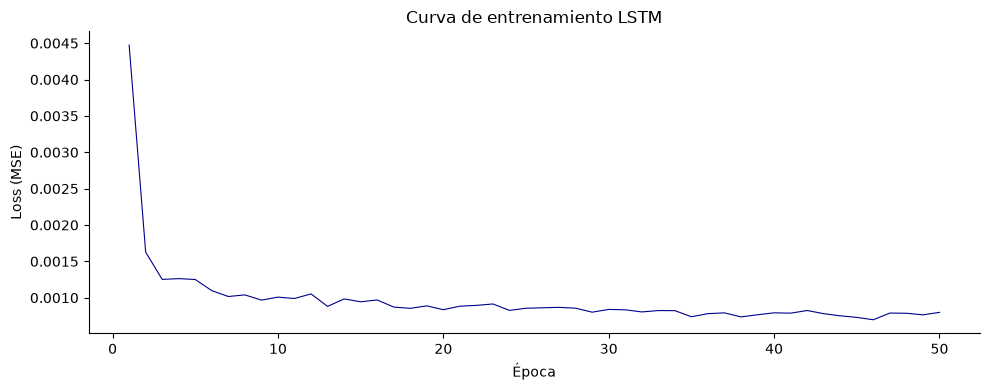

MAE:  34.37 $/kWh
RMSE: 47.55 $/kWh
MAPE: 15.18%


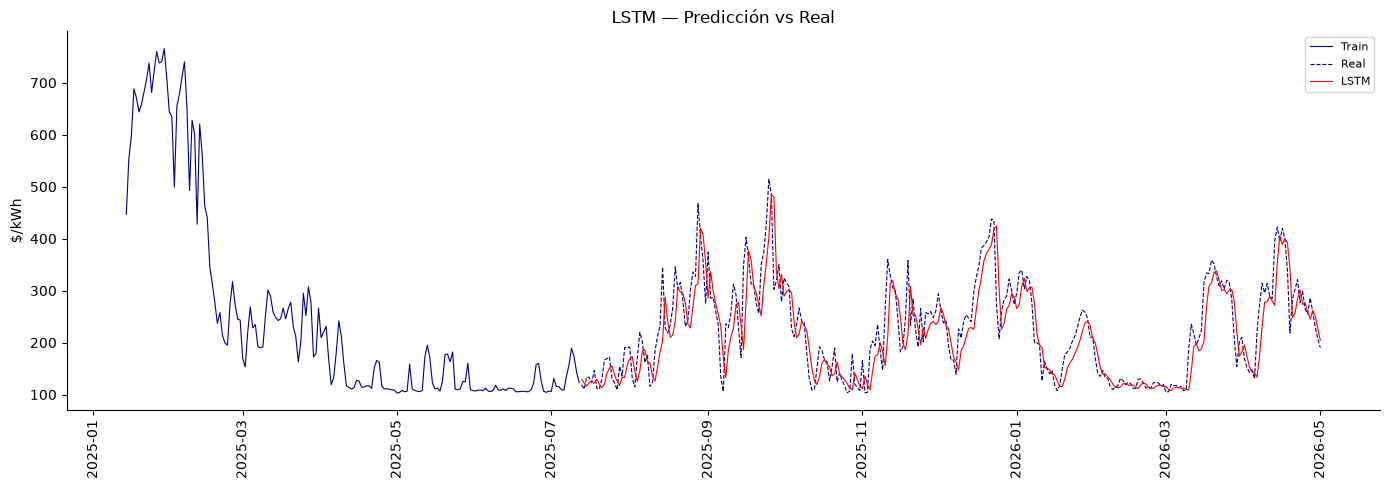

In [5]:
# Curva de entrenamiento
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, EPOCHS+1), historial, color='darkblue', linewidth=0.8)
ax.set_xlabel('Época')
ax.set_ylabel('Loss (MSE)')
ax.set_title('Curva de entrenamiento LSTM')
sns.despine()
plt.tight_layout()
plt.show()

# Predicciones
modelo_lstm.eval()
with torch.no_grad():
    pred_scaled = modelo_lstm(X_test_t).cpu().numpy()

pred_lstm = scaler.inverse_transform(pred_scaled).flatten()
real = test.values

mae_lstm = np.mean(np.abs(real - pred_lstm))
rmse_lstm = np.sqrt(np.mean((real - pred_lstm)**2))
mape_lstm = np.mean(np.abs((real - pred_lstm) / real)) * 100

print(f"MAE:  {mae_lstm:.2f} $/kWh")
print(f"RMSE: {rmse_lstm:.2f} $/kWh")
print(f"MAPE: {mape_lstm:.2f}%")

# Gráfica predicción vs real
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index[-180:], train.values[-180:], color='darkblue', linewidth=0.8, label='Train')
ax.plot(test.index, real, color='darkblue', linewidth=0.8, linestyle='--', label='Real')
ax.plot(test.index, pred_lstm, color='red', linewidth=0.8, label='LSTM')
ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title('LSTM — Predicción vs Real')
sns.despine()
plt.tight_layout()
plt.show()

In [6]:
PROCESSED = Path.cwd().parents[1] / 'data' / 'processed'

pred_df_dl = pd.DataFrame({
    'real': test.values,
    'lstm': pred_lstm
}, index=test.index)

pred_df_dl.to_parquet(PROCESSED / 'predicciones_dl.parquet')
print("Guardado")

Guardado


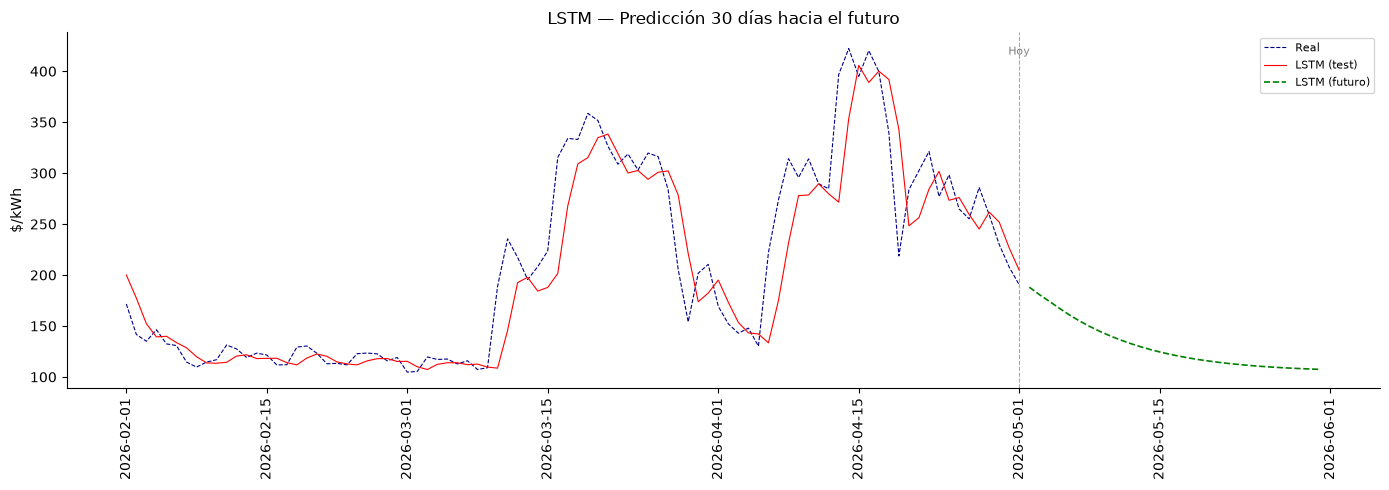


Predicción próximos 30 días:
            precio_bolsa_pred
Fecha                        
2026-05-02             188.07
2026-05-03             180.77
2026-05-04             174.15
2026-05-05             167.30
2026-05-06             160.82
2026-05-07             154.93
2026-05-08             149.62
2026-05-09             144.83
2026-05-10             140.49
2026-05-11             136.58
2026-05-12             133.05
2026-05-13             129.88
2026-05-14             127.04
2026-05-15             124.51
2026-05-16             122.24
2026-05-17             120.22
2026-05-18             118.43
2026-05-19             116.84
2026-05-20             115.42
2026-05-21             114.17
2026-05-22             113.06
2026-05-23             112.08
2026-05-24             111.21
2026-05-25             110.45
2026-05-26             109.77
2026-05-27             109.17
2026-05-28             108.65
2026-05-29             108.18
2026-05-30             107.77
2026-05-31             107.41


In [7]:
# Últimos 30 días del test como ventana inicial
ventana_inicial = test_scaled[-VENTANA:].reshape(1, VENTANA, 1)
ventana_actual = torch.FloatTensor(ventana_inicial).to(device)

predicciones_futuro = []

modelo_lstm.eval()
with torch.no_grad():
    for _ in range(30):
        pred = modelo_lstm(ventana_actual)
        predicciones_futuro.append(pred.item())
        # Actualizar ventana deslizando
        nueva_ventana = torch.cat([ventana_actual[:, 1:, :], pred.unsqueeze(0)], dim=1)
        ventana_actual = nueva_ventana

# Desnormalizar
pred_futuro = scaler.inverse_transform(
    np.array(predicciones_futuro).reshape(-1, 1)
).flatten()

# Fechas futuras
fechas_futuro = pd.date_range(
    start=test.index[-1] + pd.Timedelta(days=1), periods=30
)

# Gráfica
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index[-90:], test.values[-90:], color='darkblue', 
        linewidth=0.8, linestyle='--', label='Real')
ax.plot(test.index[-90:], pred_lstm[-90:], color='red', 
        linewidth=0.8, label='LSTM (test)')
ax.plot(fechas_futuro, pred_futuro, color='green', 
        linewidth=1.2, linestyle='--', label='LSTM (futuro)')
ax.axvline(test.index[-1], color='gray', linestyle='--', 
           linewidth=0.8, alpha=0.7)
ax.text(test.index[-1], ax.get_ylim()[1]*0.95, 'Hoy', 
        fontsize=8, color='gray', ha='center')
ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title('LSTM — Predicción 30 días hacia el futuro')
sns.despine()
plt.tight_layout()
plt.show()

print(f"\nPredicción próximos 30 días:")
df_futuro = pd.DataFrame({'Fecha': fechas_futuro, 'precio_bolsa_pred': pred_futuro.round(2)})
df_futuro = df_futuro.set_index('Fecha')
print(df_futuro)

In [8]:
pred_df_dl = pd.DataFrame({
    'real': test.values,
    'lstm': pred_lstm
}, index=test.index)

pred_df_dl.to_parquet(PROCESSED / 'predicciones_dl.parquet')
print("Guardado")

Guardado
